In [32]:
## conda activate gpy_torch_env
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

import tqdm
import torch 
from torch.autograd.functional import jacobian
from torch.distributions.multivariate_normal import MultivariateNormal
import gpytorch
import pyro
from pyro.infer import MCMC, NUTS
import pyro.distributions as dist
from scipy.linalg import eigh
import numpy as np 
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp
from scipy.stats import norm, multivariate_normal, invgamma, uniform
from scipy import interpolate
import pickle



In [33]:
parameter_names_4spring = ['$k_1$','$c_1$','$k_2$','$c_2$','$k_3$','$c_3$','$k_4$','$c_4$']
parameter_names_2spring = ['$k_1$','$c_1$','$k_2$','$c_2$']
parameter_names_SIRV = ['$a$','$v$','$\mu$','$w_r$','$w_v$']
parameter_names_FItz = ['$a$','$b$','$I$','$\\tau$']

state_names_4spring = ['$x_1$','$x_2$','$x_3$','$x_4$']
state_names_2spring = ['$x_1$','$x_2$']
state_names_IRV = ['$I$','$R$','$V$']
state_names_IV = ['$I$','$V$']
state_names_fitz = ['$v$','$w$']




<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
C:\Users\mjcol\AppData\Local\Temp\ipykernel_23632\1652321279.py:3: SyntaxWarning: invalid escape sequence '\m'
  parameter_names_SIRV = ['$a$','$v$','$\mu$','$w_r$','$w_v$']


tensor([[0.4143, 0.1558, 0.1930, 0.0264],
        [0.1558, 0.5528, 0.3532, 0.0442],
        [0.1930, 0.3532, 0.6333, 0.0922],
        [0.0264, 0.0442, 0.0922, 0.3494]])
condition number: 4.648319721221924
tensor([[ 1.5121,  0.7787,  0.1496, -0.0301],
        [ 0.7787,  1.3571,  0.7465,  0.1527],
        [ 0.1496,  0.7465,  1.2129,  0.5683],
        [-0.0301,  0.1527,  0.5683,  1.3518]])
condition number: 8.806940078735352
tensor([[ 1.0476,  0.9320,  0.7669, -0.1698],
        [ 0.9320,  4.8313,  4.4686,  2.3077],
        [ 0.7669,  4.4686,  4.4826,  2.9492],
        [-0.1698,  2.3077,  2.9492,  5.1271]])
condition number: 108.10134887695312
tensor([[19.1750,  4.9043, -2.6758, -0.0489],
        [ 4.9043,  7.5154,  5.1528, -0.3944],
        [-2.6758,  5.1528,  9.0437, -0.3927],
        [-0.0489, -0.3944, -0.3927,  4.0587]])
condition number: 15.205270767211914
tensor([[ 0.9295,  0.8004,  0.5739, -0.2386],
        [ 0.8004,  1.2427,  0.9972, -0.1892],
        [ 0.5739,  0.9972,  1.2157,  0

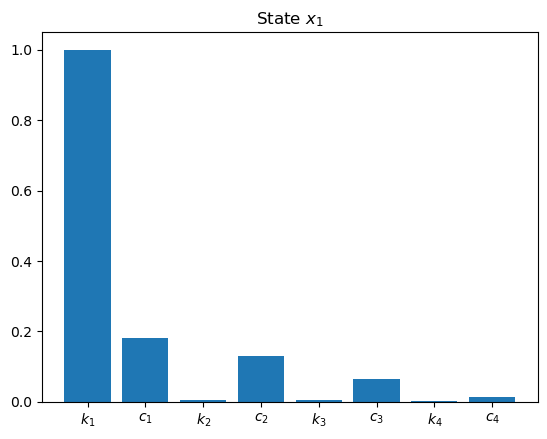

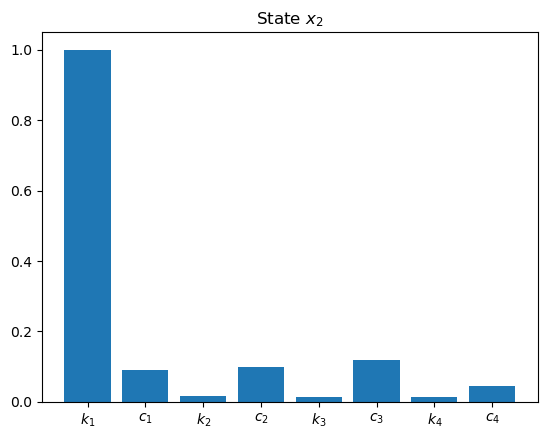

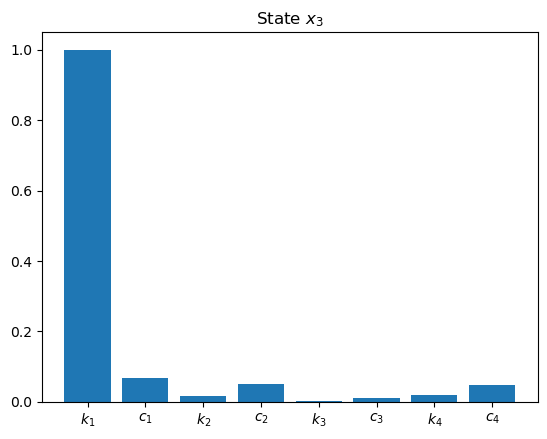

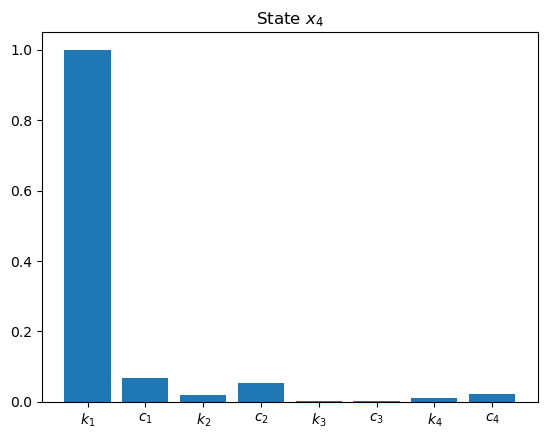

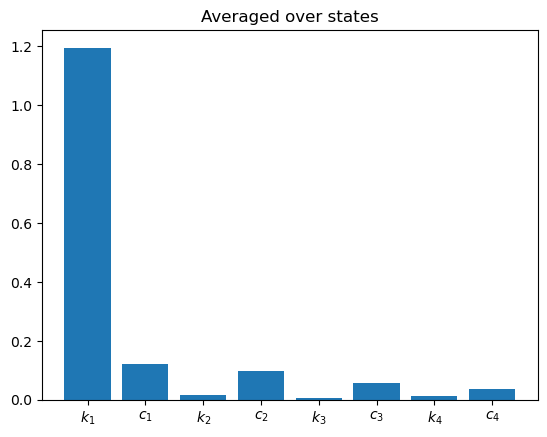

In [66]:
## Spring Problem
num_par = 8 #leave off discrepancy hyperparameters
J = 4
burnin = 2000
from Four_Spring_Model import call_model as call_model_4spring
from Run_FourSpring_AMwithGibbs_100signals import compute_jacobian as jac_4spring
sens_fourspring = torch.zeros((100,J,num_par))

for i in range(10):
    if i<10:
        # fname = 'Fitz_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        fname = 'FourSpring_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_100signal_results/signal_00'+f'{i}' + '_results.pkl'
    else:
        # fname = 'Fitz_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        fname = 'FourSpring_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_100signal_results/signal_0'+f'{i}' + '_results.pkl'

    

    with open(fname, 'rb') as f:
        data = pickle.load(f)

    tvals = torch.tensor(data['tvals'])
    F_true = data['force_true']
    n_grid = len(tvals)
    t_obs = data['t_obs']
    xi_true = data['xi_true']
    y_obs = data['obs']

    l2_par = data['x_sorted'][0,:]
    data_generating_par = data['theta_all_true']


    states = call_model_4spring(data_generating_par[:num_par].flatten(),tvals,F_true)
    S = torch.zeros((n_grid*num_par,J))
    for ii in range(J):
        sens_fourspring[i,ii,:] = torch.sum(states[ii+(num_par)::8,:].T**2,dim=0)
        S[:,ii] = states[ii+(num_par)::8,:].flatten()

    
    print(torch.matmul(S.T,S))
    print(fr'condition number: {torch.linalg.cond(torch.matmul(S.T,S))}')
sens_avg = torch.mean(sens_fourspring,dim=0)
for ii in range(J):
    plt.figure()
    plt.bar(x=np.arange(num_par),height=sens_avg[ii,:]/torch.max(sens_avg[ii,:]))
    plt.xticks(ticks=np.arange(num_par),labels=parameter_names_4spring)
    plt.title(fr"State {state_names_4spring[ii]}")
    plt.show()

plt.figure()
plt.bar(x=np.arange(num_par),height=torch.mean(sens_avg,dim=0))
plt.xticks(ticks=np.arange(num_par),labels=parameter_names_4spring)
plt.title('Averaged over states')
plt.show()


    
    



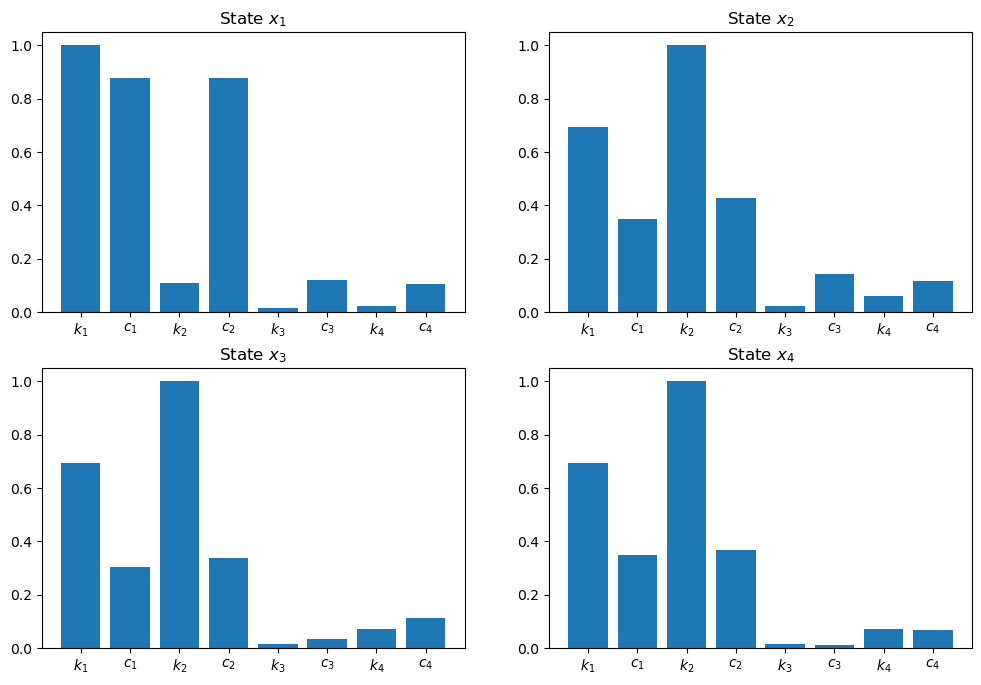

tensor([11.2335,  6.5752, 12.3124,  7.0816,  0.2430,  1.0758,  0.8632,  1.4779])


Text(0.5, 1.0, 'Objective Function Sensitivity')

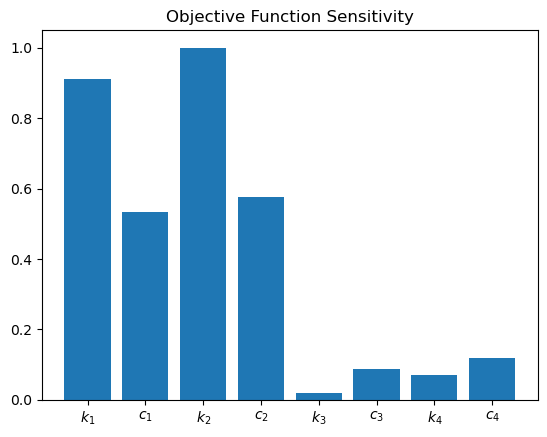

In [51]:
sens_avg = torch.mean(sens_fourspring,dim=0)
J=4
num_par=8
plt.figure(figsize=(12,8))
for ii in range(J):
    plt.subplot(2,2,ii+1)
    plt.bar(x=np.arange(num_par),height=sens_avg[ii,:]/torch.max(sens_avg[ii,:]))
    plt.xticks(ticks=np.arange(num_par),labels=parameter_names_4spring)
    plt.title(fr"State {state_names_4spring[ii]}")
plt.show()

sens_sum = torch.sum(sens_avg,dim=0)
print(sens_sum)
plt.figure()
plt.bar(x=np.arange(num_par),height=sens_sum/torch.max(sens_sum))
plt.xticks(ticks=np.arange(num_par),labels=parameter_names_4spring)
plt.title("Objective Function Sensitivity")


tensor([[0.9691, 0.3908],
        [0.3908, 0.9183]])
condition number: 2.4190330505371094
tensor([[ 1.0904,  1.4087],
        [ 1.4087, 54.6012]])
condition number: 51.87108612060547
tensor([[1.6306, 1.0681],
        [1.0681, 2.5179]])
condition number: 3.5208499431610107
tensor([[2.5978, 2.1598],
        [2.1598, 4.5930]])
condition number: 4.9120330810546875
tensor([[0.7738, 0.4026],
        [0.4026, 3.8115]])
condition number: 5.356748104095459
tensor([[16.1524, -1.2694],
        [-1.2694,  4.6312]])
condition number: 3.62579083442688
tensor([[14.3133, -0.4953],
        [-0.4953,  3.6227]])
condition number: 3.9825310707092285
tensor([[32.7607,  2.1873],
        [ 2.1873, 42.9265]])
condition number: 1.342526912689209
tensor([[1.1182, 1.0531],
        [1.0531, 1.9491]])
condition number: 6.638136386871338
tensor([[2.0408, 1.1182],
        [1.1182, 2.7411]])
condition number: 2.922078847885132


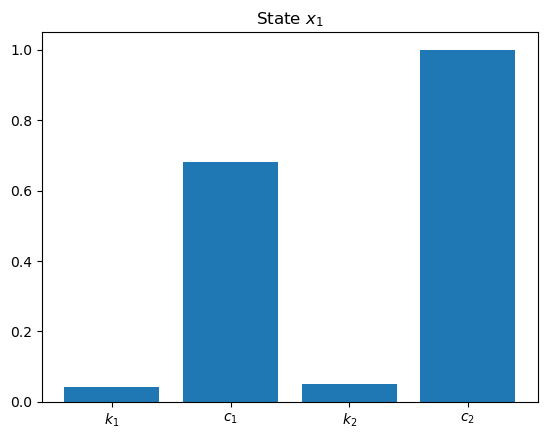

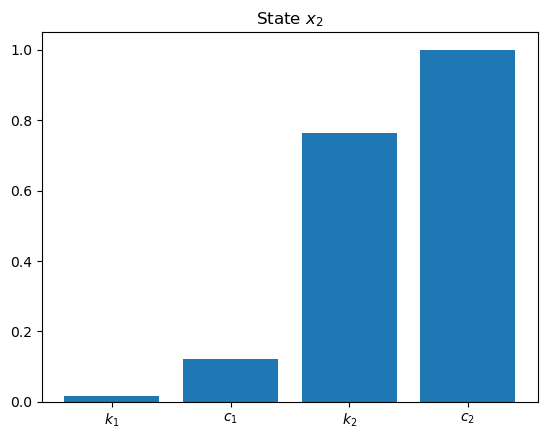

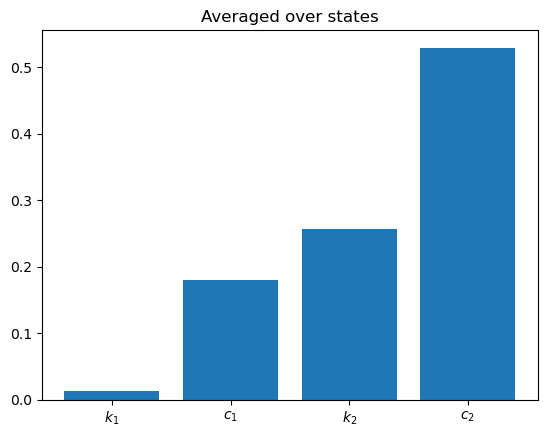

In [67]:
## Spring Problem
num_par = 4 #leave off discrepancy hyperparameters
J = 2
burnin = 2000
from Run_TwoSpring_AMwithGibbs_100signals import call_model as call_model_2spring
from Run_TwoSpring_AMwithGibbs_100signals import compute_jacobian as jac_2spring

sens_twospring = torch.zeros((100,J,num_par))

for i in range(10):
    if i<10:
        # fname = 'Fitz_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        fname = 'TwoSpring_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_100signal_results/signal_00'+f'{i}' + '_results.pkl'
    else:
        # fname = 'Fitz_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        fname = 'TwoSpring_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_100signal_results/signal_0'+f'{i}' + '_results.pkl'

    

    with open(fname, 'rb') as f:
        data = pickle.load(f)

    chain_IND_all = data['chain_IND_all']
    chain_MOP_all = data['chain_MOP_all']
    s2chain_IND_all = data['s2chain_IND_all']
    s2chain_MOP_all = data['s2chain_MOP_all']
    tvals = torch.tensor(data['tvals'])
    F_true = data['force_true']
    n_grid = len(tvals)
    t_obs = data['t_obs']
    xi_true = data['xi_true']
    y_obs = data['obs']

    l2_par = data['x_sorted'][0,:]
    data_generating_par = data['theta_all_true']

    S = torch.zeros((n_grid*num_par,J))
    states = call_model_2spring(data_generating_par[:num_par].flatten(),tvals,F_true)
    for ii in range(J):
        sens_twospring[i,ii,:] = torch.sum(states[ii+(num_par)::4,:].T**2,dim=0)
        S[:,ii] = states[ii+(num_par)::4,:].flatten()

    print(torch.matmul(S.T,S))
    print(fr'condition number: {torch.linalg.cond(torch.matmul(S.T,S))}')

sens_avg = torch.mean(sens_twospring,dim=0)
for ii in range(J):
    plt.figure()
    plt.bar(x=np.arange(num_par),height=sens_avg[ii,:]/torch.max(sens_avg[ii,:]))
    plt.xticks(ticks=np.arange(num_par),labels=parameter_names_2spring)
    plt.title(fr"State {state_names_2spring[ii]}")
    plt.show()

plt.figure()
plt.bar(x=np.arange(num_par),height=torch.mean(sens_avg,dim=0))
plt.xticks(ticks=np.arange(num_par),labels=parameter_names_2spring)
plt.title('Averaged over states')
plt.show()
    




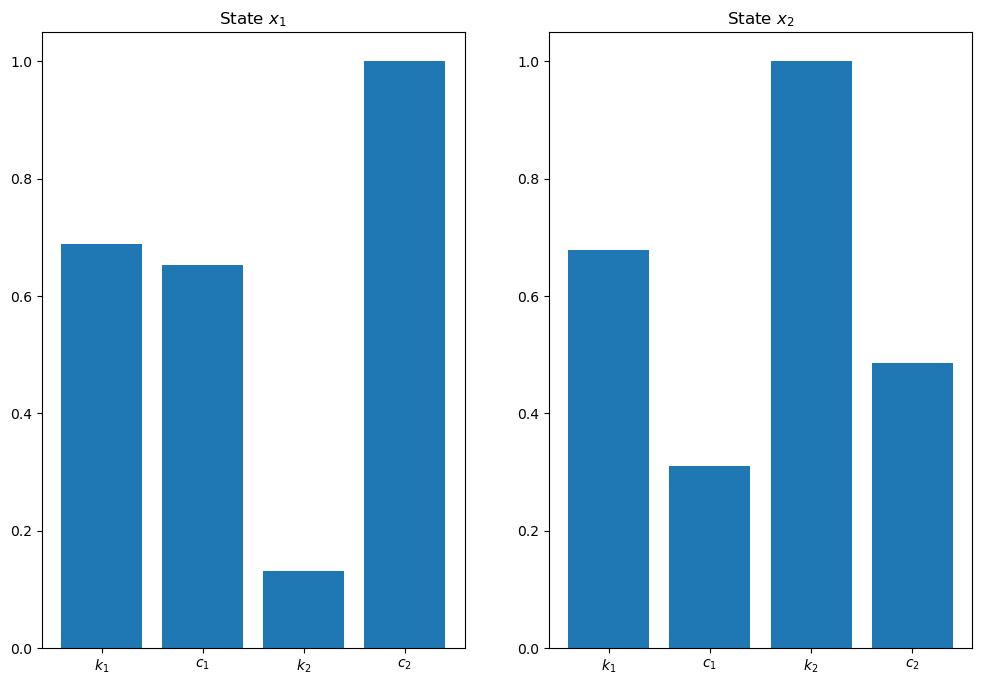

tensor([10.7939,  7.5301,  9.1181, 11.6262])


Text(0.5, 1.0, 'Objective Function Sensitivity')

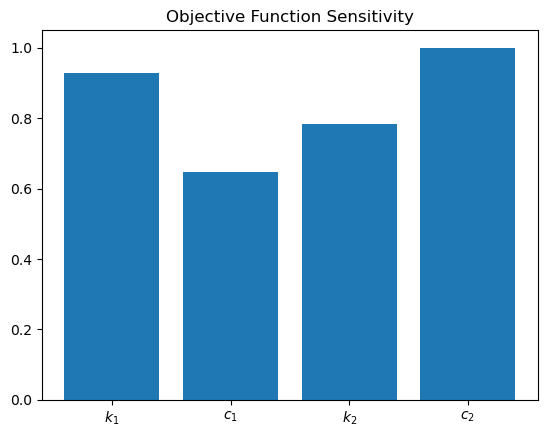

In [52]:
sens_avg = torch.mean(sens_twospring,dim=0)
J=2
num_par=4
plt.figure(figsize=(12,8))
for ii in range(J):
    plt.subplot(1,2,ii+1)
    plt.bar(x=np.arange(num_par),height=sens_avg[ii,:]/torch.max(sens_avg[ii,:]))
    plt.xticks(ticks=np.arange(num_par),labels=parameter_names_2spring)
    plt.title(fr"State {state_names_2spring[ii]}")
plt.show()


sens_sum = torch.sum(sens_avg,dim=0)
print(sens_sum)
plt.figure()
plt.bar(x=np.arange(num_par),height=sens_sum/torch.max(sens_sum))
plt.xticks(ticks=np.arange(num_par),labels=parameter_names_2spring)
plt.title("Objective Function Sensitivity")

    


torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])


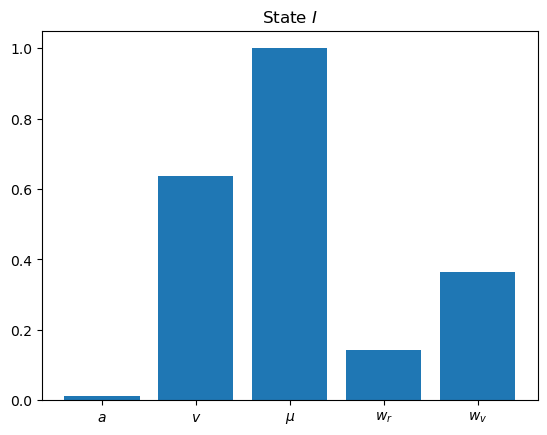

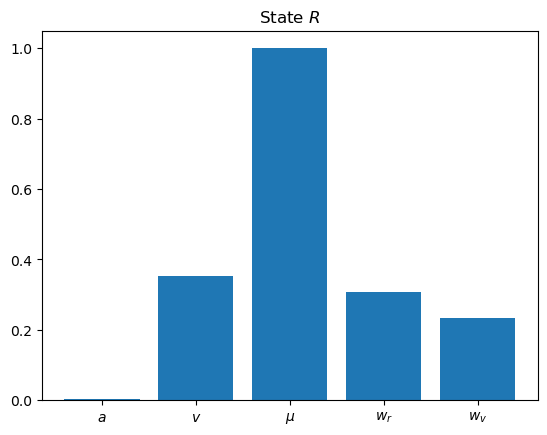

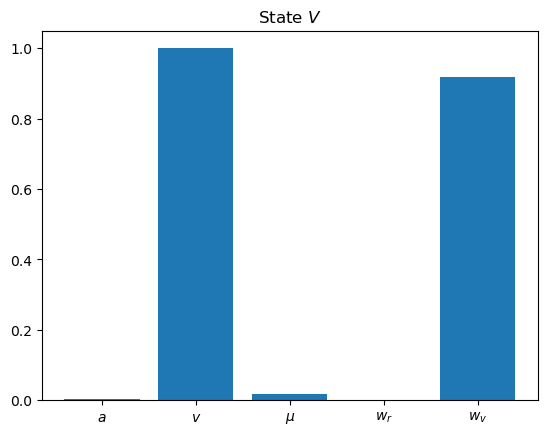

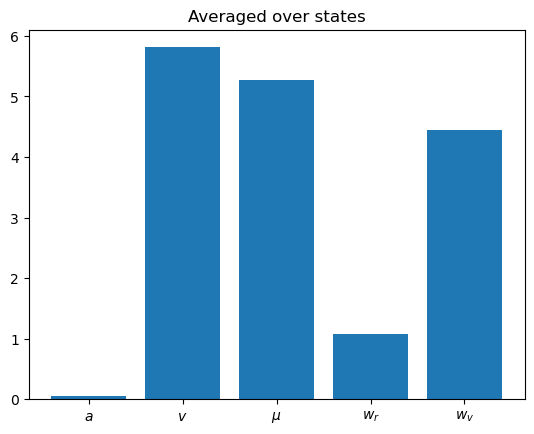

In [36]:
## Spring Problem
num_par = 5 #leave off discrepancy hyperparameters
J = 3
burnin = 2000
from Run_SIRV_IRV_AMwithGibbs_100signals import call_model as call_model_IRV
from Run_SIRV_IRV_AMwithGibbs_100signals import compute_jacobian as jac_IRV

sens_IRV = torch.zeros((100,J,num_par))
# Helper function since IRV model gives back all four states, we just need the last three


for i in range(100):
    if i<10:
        # fname = 'Fitz_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        fname = 'SIRV_IRV_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_100signal_results/signal_00'+f'{i}' + '_results.pkl'
    else:
        # fname = 'Fitz_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        fname = 'SIRV_IRV_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_100signal_results/signal_0'+f'{i}' + '_results.pkl'

    

    with open(fname, 'rb') as f:
        data = pickle.load(f)

    chain_IND_all = data['chain_IND_all']
    chain_MOP_all = data['chain_MOP_all']
    s2chain_IND_all = data['s2chain_IND_all']
    s2chain_MOP_all = data['s2chain_MOP_all']
    tvals = torch.tensor(data['tvals'])
    n_grid = len(tvals)
    t_obs = data['t_obs']
    xi_true = data['xi_true']
    y_obs = data['obs']

    l2_par = data['x_sorted'][0,:]
    data_generating_par = data['theta_all_true']

    
    states = call_model_IRV(data_generating_par[:num_par].flatten(),tvals)
    for ii in range(J):
        # Add one for skipping S state
        ii_mod = ii+1
        print(np.shape(states[ii_mod+(4)::4,:].T))
        sens_IRV[i,ii,:] = torch.sum(states[ii_mod+(4)::4,:].T**2,dim=0)

sens_avg = torch.mean(sens_IRV,dim=0)
for ii in range(J):
    plt.figure()
    plt.bar(x=np.arange(num_par),height=sens_avg[ii,:]/torch.max(sens_avg[ii,:]))
    plt.xticks(ticks=np.arange(num_par),labels=parameter_names_SIRV)
    plt.title(fr"State {state_names_IRV[ii]}")
    plt.show()

plt.figure()
plt.bar(x=np.arange(num_par),height=torch.mean(sens_avg,dim=0))
plt.xticks(ticks=np.arange(num_par),labels=parameter_names_SIRV)
plt.title('Averaged over states')
plt.show()
    
    




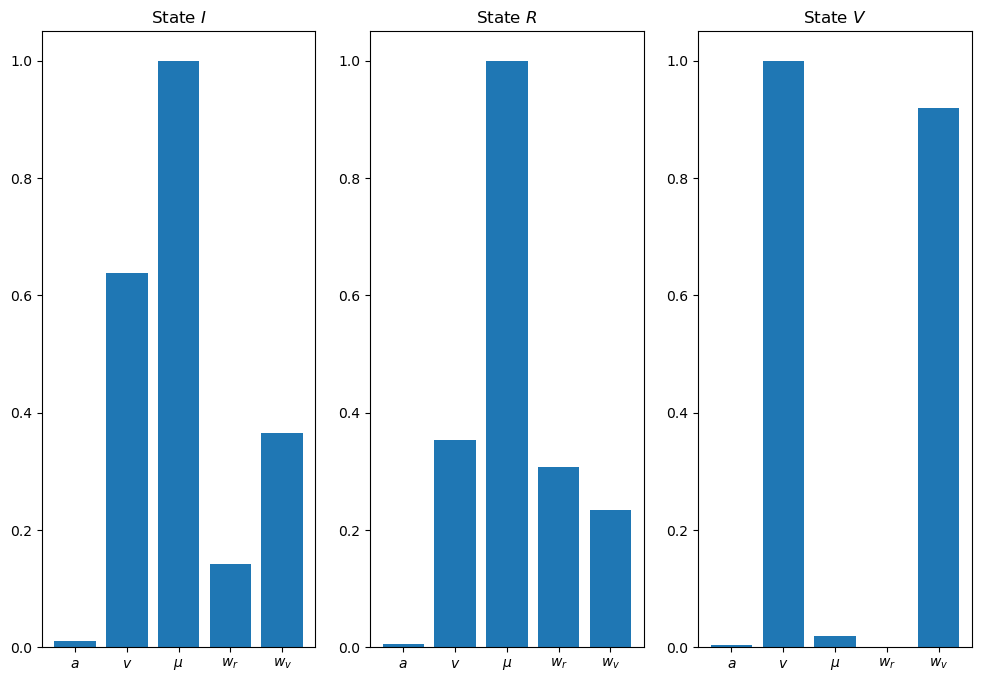

tensor([ 0.1684, 17.4344, 15.8074,  3.2404, 13.3604])


Text(0.5, 1.0, 'Objective Function Sensitivity')

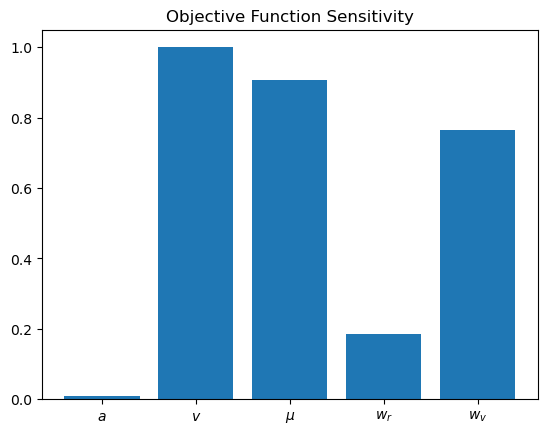

In [54]:
sens_avg = torch.mean(sens_IRV,dim=0)
J=3
num_par=5
plt.figure(figsize=(12,8))
for ii in range(J):
    plt.subplot(1,3,ii+1)
    plt.bar(x=np.arange(num_par),height=sens_avg[ii,:]/torch.max(sens_avg[ii,:]))
    plt.xticks(ticks=np.arange(num_par),labels=parameter_names_SIRV)
    plt.title(fr"State {state_names_IRV[ii]}")
plt.show()


sens_sum = torch.sum(sens_avg,dim=0)
print(sens_sum)
plt.figure()
plt.bar(x=np.arange(num_par),height=sens_sum/torch.max(sens_sum))
plt.xticks(ticks=np.arange(num_par),labels=parameter_names_SIRV)
plt.title("Objective Function Sensitivity")

    


    


torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])
torch.Size([50, 5])


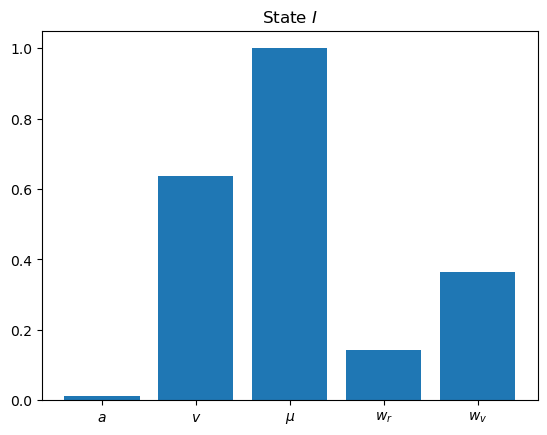

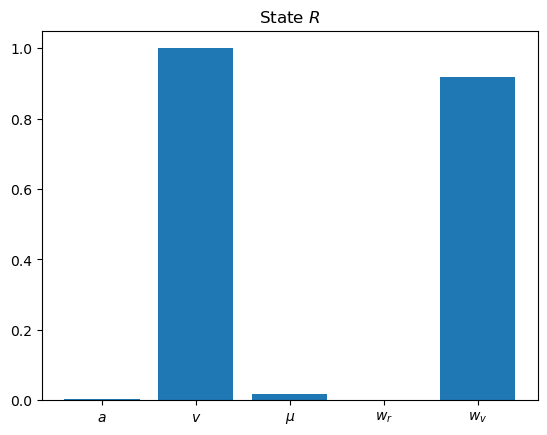

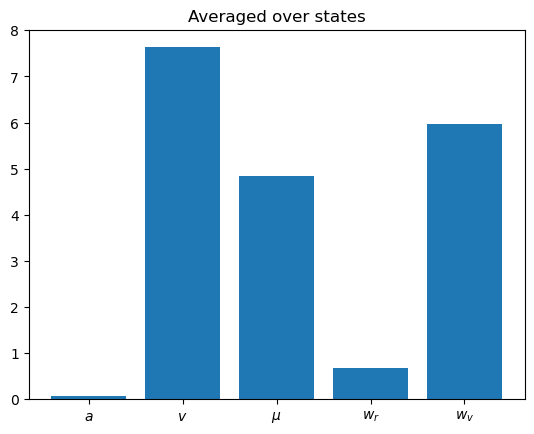

In [37]:
## Spring Problem
num_par = 5 #leave off discrepancy hyperparameters
J = 2
burnin = 2000
from Run_SIRV_IV_AMwithGibbs_100signals import call_model as call_model_IV
from Run_SIRV_IV_AMwithGibbs_100signals import compute_jacobian as jac_IV

sens_IV = torch.zeros((100,J,num_par))


for i in range(100):
    if i<10:
        # fname = 'Fitz_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        fname = 'SIRV_IV_100signal_results/signal_00'+f'{i}' + '_results.pkl'
    else:
        # fname = 'Fitz_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        fname = 'SIRV_IV_100signal_results/signal_0'+f'{i}' + '_results.pkl'

    

    with open(fname, 'rb') as f:
        data = pickle.load(f)

    chain_IND_all = data['chain_IND_all']
    chain_MOP_all = data['chain_MOP_all']
    s2chain_IND_all = data['s2chain_IND_all']
    s2chain_MOP_all = data['s2chain_MOP_all']
    tvals = torch.tensor(data['tvals'])
    n_grid = len(tvals)
    t_obs = data['t_obs']
    xi_true = data['xi_true']
    y_obs = data['obs']

    l2_par = data['x_sorted'][0,:]
    data_generating_par = data['theta_all_true']

    

    
    states = call_model_IV(data_generating_par[:num_par].flatten(),tvals)
    for ii in range(J):
        # Add one for skipping S state
        if (ii==0):
            ii_mod = ii+1
        else:
            ii_mod=ii+2
        print(np.shape(states[ii_mod+(4)::4,:].T))
        sens_IV[i,ii,:] = torch.sum(states[ii_mod+(4)::4,:].T**2,dim=0)
    
sens_avg = torch.mean(sens_IV,dim=0)
for ii in range(J):
    plt.figure()
    plt.bar(x=np.arange(num_par),height=sens_avg[ii,:]/torch.max(sens_avg[ii,:]))
    plt.xticks(ticks=np.arange(num_par),labels=parameter_names_SIRV)
    plt.title(fr"State {state_names_IRV[ii]}")
    plt.show()
    
plt.figure()
plt.bar(x=np.arange(num_par),height=torch.mean(sens_avg,dim=0))
plt.xticks(ticks=np.arange(num_par),labels=parameter_names_SIRV)
plt.title('Averaged over states')
plt.show()
        


    




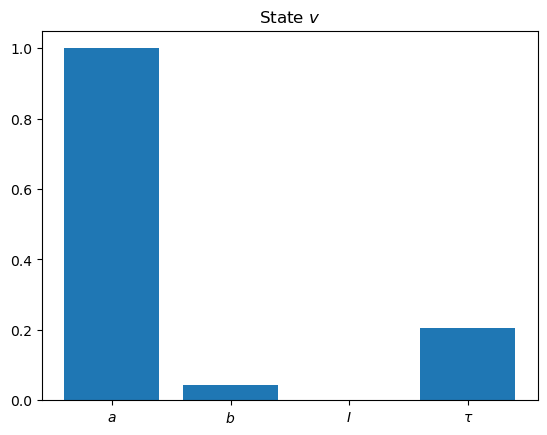

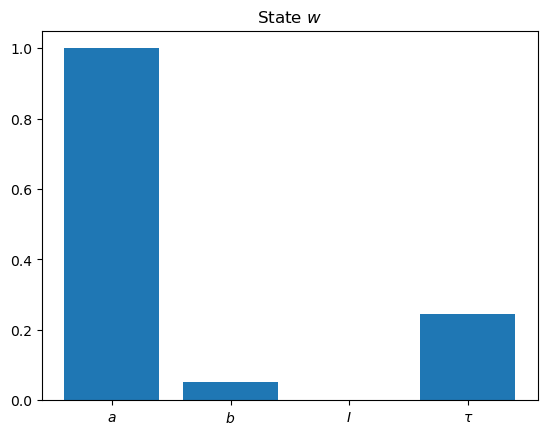

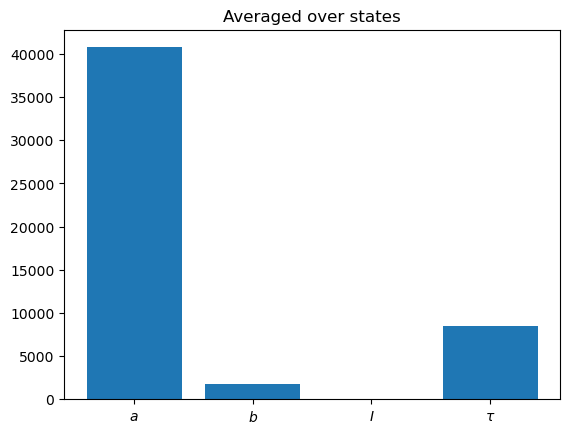

In [38]:
## Spring Problem
num_par = 4 #leave off discrepancy hyperparameters
J = 2
burnin = 2000
from Run_Fitz_AMwithGibbs_100signals import call_model as call_model_Fitz
from Run_Fitz_AMwithGibbs_100signals import compute_jacobian as jac_Fitz

sens_fitz = torch.zeros((100,J,num_par))

for i in range(100):
    if i<10:
        fname = 'Fitz_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_100signal_results/signal_00'+f'{i}' + '_results.pkl'
    else:
        fname = 'Fitz_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_100signal_results/signal_0'+f'{i}' + '_results.pkl'

    

    with open(fname, 'rb') as f:
        data = pickle.load(f)

    chain_IND_all = data['chain_IND_all']
    chain_MOP_all = data['chain_MOP_all']
    s2chain_IND_all = data['s2chain_IND_all']
    s2chain_MOP_all = data['s2chain_MOP_all']
    tvals = torch.tensor(data['tvals'])
    n_grid = len(tvals)
    t_obs = data['t_obs']
    xi_true = data['xi_true']
    y_obs = data['obs']

    l2_par = data['x_sorted'][0,:]
    data_generating_par = data['theta_all_true']

    
    states = call_model_Fitz(data_generating_par[:num_par].flatten(),tvals)
    for ii in range(J):
        sens_fitz[i,ii,:] = torch.sum(states[ii+(2)::2,:].T**2,dim=0)
    
sens_avg = torch.mean(sens_fitz,dim=0)
for ii in range(J):
    plt.figure()
    plt.bar(x=np.arange(num_par),height=sens_avg[ii,:]/torch.max(sens_avg[ii,:]))
    plt.xticks(ticks=np.arange(num_par),labels=parameter_names_FItz)
    plt.title(fr"State {state_names_fitz[ii]}")
    plt.show()
    
plt.figure()
plt.bar(x=np.arange(num_par),height=torch.mean(sens_avg,dim=0))
plt.xticks(ticks=np.arange(num_par),labels=parameter_names_FItz)
plt.title('Averaged over states')
plt.show()




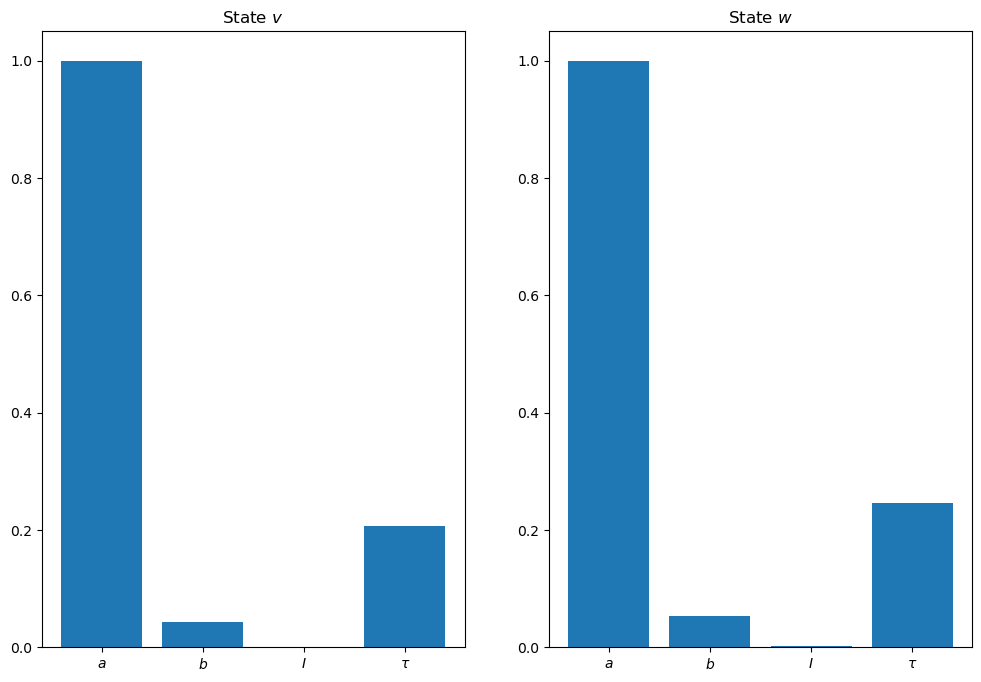

tensor([81523.3750,  3500.5527,   100.1752, 16970.6699])


Text(0.5, 1.0, 'Objective Function Sensitivity')

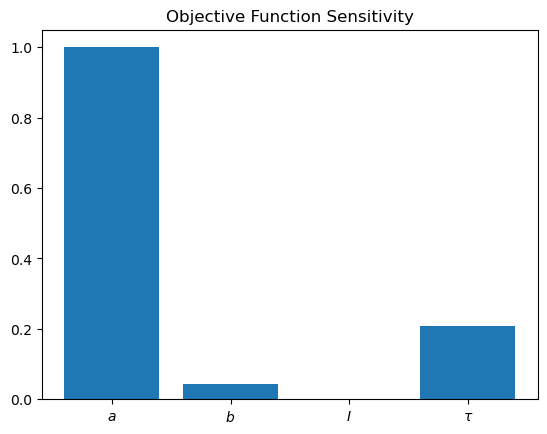

In [55]:
sens_avg = torch.mean(sens_fitz,dim=0)
J=2
num_par=4
plt.figure(figsize=(12,8))
for ii in range(J):
    plt.subplot(1,2,ii+1)
    plt.bar(x=np.arange(num_par),height=sens_avg[ii,:]/torch.max(sens_avg[ii,:]))
    plt.xticks(ticks=np.arange(num_par),labels=parameter_names_FItz)
    plt.title(fr"State {state_names_fitz[ii]}")
plt.show()


sens_sum = torch.sum(sens_avg,dim=0)
print(sens_sum)
plt.figure()
plt.bar(x=np.arange(num_par),height=sens_sum/torch.max(sens_sum))
plt.xticks(ticks=np.arange(num_par),labels=parameter_names_FItz)
plt.title("Objective Function Sensitivity")
